<a href="https://colab.research.google.com/github/PatJosh-Codes/AI-Image-Detector/blob/main/Cross_Generalization_in_deepfake_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/access_token', 'w') as f:
    f.write('KGAT_38d5ddcc4070d251a1f4ae0780743513')

!chmod 600 /root/.kaggle/access_token

In [ ]:
!kaggle datasets list

ref                                                               title                                              size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  -------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
debayank2024/netflix-movies-and-series                            Netflix Movies and Series                       1400865  2026-07-27 09:40:46.527000           6258        150                1  
harshadapatil31/student-performance-and-study-habits-dataset      Student Performance & Study Habits Dataset        15035  2026-07-06 06:28:52.743000          12777        249                1  
srisyra02/spotify-music-artist-streaming-analytics                Spotify Music Artist Streaming Analytics          23463  2026-08-07 03:20:03.313000           2178         34                1  
debayank2024/house-price-

In [ ]:
!pip install --upgrade kaggle --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.5 MB/s eta 0:00:00


In [ ]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d gan_raw

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:29<00:00, 138MB/s]



In [ ]:
!find gan_raw -maxdepth 3 -type d

gan_raw
gan_raw/real_vs_fake
gan_raw/real_vs_fake/real-vs-fake
gan_raw/real_vs_fake/real-vs-fake/train
gan_raw/real_vs_fake/real-vs-fake/valid
gan_raw/real_vs_fake/real-vs-fake/test


In [ ]:
!find gan_raw/real_vs_fake/real-vs-fake/train -maxdepth 1 -type d

gan_raw/real_vs_fake/real-vs-fake/train
gan_raw/real_vs_fake/real-vs-fake/train/fake
gan_raw/real_vs_fake/real-vs-fake/train/real


In [ ]:
"""
Sort GAN subset: sample 2000 real + 2000 fake images from the downloaded
'140k-real-and-fake-faces' Kaggle dataset into the clean data/gan/{real,fake}
structure expected by train_eval.py.

Run this in Colab AFTER downloading + unzipping the Kaggle dataset:
    !kaggle datasets download -d xhlulu/140k-real-and-fake-faces
    !unzip -q 140k-real-and-fake-faces.zip -d gan_raw
"""

import os
import random
import shutil
from pathlib import Path

random.seed(42)

SOURCE_ROOT = Path("gan_raw/real_vs_fake/real-vs-fake/train")
DEST_ROOT = Path("data/gan")
N_PER_CLASS = 2000

for cls in ["real", "fake"]:
    src_dir = SOURCE_ROOT / cls
    dst_dir = DEST_ROOT / cls
    dst_dir.mkdir(parents=True, exist_ok=True)

    all_files = [p for p in src_dir.glob("*") if p.suffix.lower() in {".png", ".jpg", ".jpeg"}]
    print(f"[{cls}] found {len(all_files)} images in {src_dir}")

    if len(all_files) < N_PER_CLASS:
        raise RuntimeError(
            f"Only {len(all_files)} images available in {src_dir}, "
            f"need {N_PER_CLASS}. Lower N_PER_CLASS or check the source path."
        )

    sampled = random.sample(all_files, N_PER_CLASS)

    for i, src_path in enumerate(sampled):
        dst_path = dst_dir / src_path.name
        shutil.copy2(src_path, dst_path)

    print(f"[{cls}] copied {len(sampled)} images -> {dst_dir}")

print("\nDone. Verify counts:")
for cls in ["real", "fake"]:
    count = len(list((DEST_ROOT / cls).glob("*")))
    print(f"  data/gan/{cls}: {count} images")

[real] found 50000 images in gan_raw/real_vs_fake/real-vs-fake/train/real
[real] copied 2000 images -> data/gan/real
[fake] found 50000 images in gan_raw/real_vs_fake/real-vs-fake/train/fake
[fake] copied 2000 images -> data/gan/fake

Done. Verify counts:
  data/gan/real: 2000 images
  data/gan/fake: 2000 images


In [ ]:
!pip install huggingface_hub --quiet

from huggingface_hub import hf_hub_download

wiki_path = hf_hub_download(
    repo_id="OpenRL/DeepFakeFace",
    filename="wiki.zip",
    repo_type="dataset"
)

text2img_path = hf_hub_download(
    repo_id="OpenRL/DeepFakeFace",
    filename="text2img.zip",
    repo_type="dataset"
)

print(wiki_path)
print(text2img_path)

wiki.zip: reconstructing file:   0%|          |  0.00B / 1.77GB            

wiki.zip: downloading bytes:           |  0.00B            

text2img.zip: reconstructing file:   0%|          |  0.00B / 1.13GB            

text2img.zip: downloading bytes:           |  0.00B            

/root/.cache/huggingface/hub/datasets--OpenRL--DeepFakeFace/snapshots/eb2a54fbf2567790bd3dc61d09fdaade6bb6c31c/wiki.zip
/root/.cache/huggingface/hub/datasets--OpenRL--DeepFakeFace/snapshots/eb2a54fbf2567790bd3dc61d09fdaade6bb6c31c/text2img.zip


In [ ]:
import os
os.makedirs("diffusion_raw/wiki", exist_ok=True)
os.makedirs("diffusion_raw/text2img", exist_ok=True)

!unzip -q "{wiki_path}" -d diffusion_raw/wiki
!unzip -q "{text2img_path}" -d diffusion_raw/text2img

In [ ]:
!find diffusion_raw -maxdepth 3 -type d

diffusion_raw
diffusion_raw/wiki
diffusion_raw/wiki/wiki
diffusion_raw/wiki/wiki/99
diffusion_raw/wiki/wiki/63
diffusion_raw/wiki/wiki/00
diffusion_raw/wiki/wiki/90
diffusion_raw/wiki/wiki/68
diffusion_raw/wiki/wiki/33
diffusion_raw/wiki/wiki/59
diffusion_raw/wiki/wiki/72
diffusion_raw/wiki/wiki/98
diffusion_raw/wiki/wiki/49
diffusion_raw/wiki/wiki/54
diffusion_raw/wiki/wiki/19
diffusion_raw/wiki/wiki/21
diffusion_raw/wiki/wiki/10
diffusion_raw/wiki/wiki/11
diffusion_raw/wiki/wiki/56
diffusion_raw/wiki/wiki/36
diffusion_raw/wiki/wiki/03
diffusion_raw/wiki/wiki/73
diffusion_raw/wiki/wiki/81
diffusion_raw/wiki/wiki/65
diffusion_raw/wiki/wiki/76
diffusion_raw/wiki/wiki/80
diffusion_raw/wiki/wiki/13
diffusion_raw/wiki/wiki/91
diffusion_raw/wiki/wiki/78
diffusion_raw/wiki/wiki/97
diffusion_raw/wiki/wiki/52
diffusion_raw/wiki/wiki/53
diffusion_raw/wiki/wiki/75
diffusion_raw/wiki/wiki/88
diffusion_raw/wiki/wiki/66
diffusion_raw/wiki/wiki/45
diffusion_raw/wiki/wiki/08
diffusion_raw/wiki/wiki/1

In [ ]:
"""
Sort Diffusion subset: sample 2000 real (wiki) + 2000 fake (text2img) images
from the downloaded DeepFakeFace dataset into the clean data/diffusion/{real,fake}
structure expected by train_eval.py.

Handles the IMDB-WIKI-style bucketed folder structure, where images sit
nested inside numbered subfolders (00-99), not flatly in one directory.

Run this in Colab AFTER downloading + unzipping:
    wiki_path = hf_hub_download(repo_id="OpenRL/DeepFakeFace", filename="wiki.zip", repo_type="dataset")
    text2img_path = hf_hub_download(repo_id="OpenRL/DeepFakeFace", filename="text2img.zip", repo_type="dataset")
    os.makedirs("diffusion_raw/wiki", exist_ok=True)
    os.makedirs("diffusion_raw/text2img", exist_ok=True)
    !unzip -q "{wiki_path}" -d diffusion_raw/wiki
    !unzip -q "{text2img_path}" -d diffusion_raw/text2img
"""

import random
import shutil
from pathlib import Path

random.seed(42)

SOURCES = {
    "real": Path("diffusion_raw/wiki/wiki"),
    "fake": Path("diffusion_raw/text2img/text2img"),
}
DEST_ROOT = Path("data/diffusion")
N_PER_CLASS = 2000
VALID_EXT = {".png", ".jpg", ".jpeg"}

for cls, src_dir in SOURCES.items():
    dst_dir = DEST_ROOT / cls
    dst_dir.mkdir(parents=True, exist_ok=True)

    # Recursive search across all numbered subfolders (00-99)
    all_files = [p for p in src_dir.rglob("*") if p.suffix.lower() in VALID_EXT]
    print(f"[{cls}] found {len(all_files)} images (recursively) under {src_dir}")

    if len(all_files) < N_PER_CLASS:
        raise RuntimeError(
            f"Only {len(all_files)} images available under {src_dir}, "
            f"need {N_PER_CLASS}. Lower N_PER_CLASS or check the source path."
        )

    sampled = random.sample(all_files, N_PER_CLASS)

    # Flatten into dest folder. Prefix filenames with their source subfolder
    # to avoid collisions, since filenames repeat across the 00-99 buckets.
    for src_path in sampled:
        bucket = src_path.parent.name  # e.g. "37"
        dst_name = f"{bucket}_{src_path.name}"
        dst_path = dst_dir / dst_name
        shutil.copy2(src_path, dst_path)

    print(f"[{cls}] copied {len(sampled)} images -> {dst_dir}")

print("\nDone. Verify counts:")
for cls in ["real", "fake"]:
    count = len(list((DEST_ROOT / cls).glob("*")))
    print(f"  data/diffusion/{cls}: {count} images")

[real] found 30000 images (recursively) under diffusion_raw/wiki/wiki
[real] copied 2000 images -> data/diffusion/real
[fake] found 30000 images (recursively) under diffusion_raw/text2img/text2img
[fake] copied 2000 images -> data/diffusion/fake

Done. Verify counts:
  data/diffusion/real: 2000 images
  data/diffusion/fake: 2000 images


In [ ]:
from google.colab import files
files.upload()

Saving train_eval.py to train_eval.py


{'train_eval.py': b'"""\nCross-Generator ViT Efficiency Study \xe2\x80\x94 Training & Evaluation Script\n=====================================================================\nRuns all 4 core experiments:\n  1. DeiT-Tiny  trained on GAN       -> tested on Diffusion (+ within-domain GAN)\n  2. DeiT-Tiny  trained on Diffusion -> tested on GAN       (+ within-domain Diffusion)\n  3. ViT-Base   trained on GAN       -> tested on Diffusion (+ within-domain GAN)\n  4. ViT-Base   trained on Diffusion -> tested on GAN       (+ within-domain Diffusion)\n\nDesigned to run on Google Colab (free T4 GPU). Expects data already\norganized locally (see DATA LAYOUT below) \xe2\x80\x94 e.g. downloaded from your\nGoogle Drive mount.\n\nDATA LAYOUT (expected, after you sort your Drive files into this structure):\n    data/\n        gan/\n            real/   *.png / *.jpg   (FFHQ subset, ~2000 images)\n            fake/   *.png / *.jpg   (StyleGAN2 subset, ~2000 images)\n        diffusion/\n            real

In [ ]:
!pip install timm torch torchvision scikit-learn --quiet
!python train_eval.py

Using device: cuda

=== deit_tiny | train=gan -> cross-test=diffusion ===

model.safetensors: downloading bytes:   0% 0.00/22.9M [00:00<?, ?B/s]
model.safetensors: downloading bytes:  94% 21.5M/22.9M [00:01<00:00, 31.3MB/s,  883kB/s  ]
model.safetensors: downloading bytes: 100% 21.7M/21.7M [00:01<00:00, 21.2MB/s, 2.11MB/s  ]
model.safetensors: reconstructing file: 100% 22.9M/22.9M [00:01<00:00, 22.3MB/s, 2.24MB/s  ]
  epoch 1/5 — loss: 0.5640
  epoch 2/5 — loss: 0.2772
  epoch 3/5 — loss: 0.1185
  epoch 4/5 — loss: 0.0789
  epoch 5/5 — loss: 0.0733
  within-domain  (gan): {'accuracy': 0.8833333333333333, 'auc': np.float64(0.9527441736345846)}
  cross-domain   (diffusion):  {'accuracy': 0.5115, 'auc': np.float64(0.48578025)}

=== deit_tiny | train=diffusion -> cross-test=gan ===
  epoch 1/5 — loss: 0.2109
  epoch 2/5 — loss: 0.0728
  epoch 3/5 — loss: 0.0390
  epoch 4/5 — loss: 0.0286
  epoch 5/5 — loss: 0.0293
  within-domain  (diffusion): {'accuracy': 0.965, 'auc': np.float64(0.988925

Markdown table:

| Model | Direction | Within-domain Acc | Cross-domain Acc | Within-domain AUC | Cross-domain AUC | Generalization Drop (Acc) |
|---|---|---|---|---|---|---|
| DeiT-Tiny (5M) | GAN → Diffusion | 0.883 | 0.511 | 0.953 | 0.486 | 0.372 |
| DeiT-Tiny (5M) | Diffusion → GAN | 0.965 | 0.567 | 0.989 | 0.602 | 0.398 |
| ViT-Base (86M) | GAN → Diffusion | 0.763 | 0.500 | 0.924 | 0.577 | 0.263 |
| ViT-Base (86M) | Diffusion → GAN | 0.940 | 0.567 | 0.988 | 0.601 | 0.373 |

Figure saved to results/generalization_drop.png and .pdf
Table saved to results/results_table.md and .csv


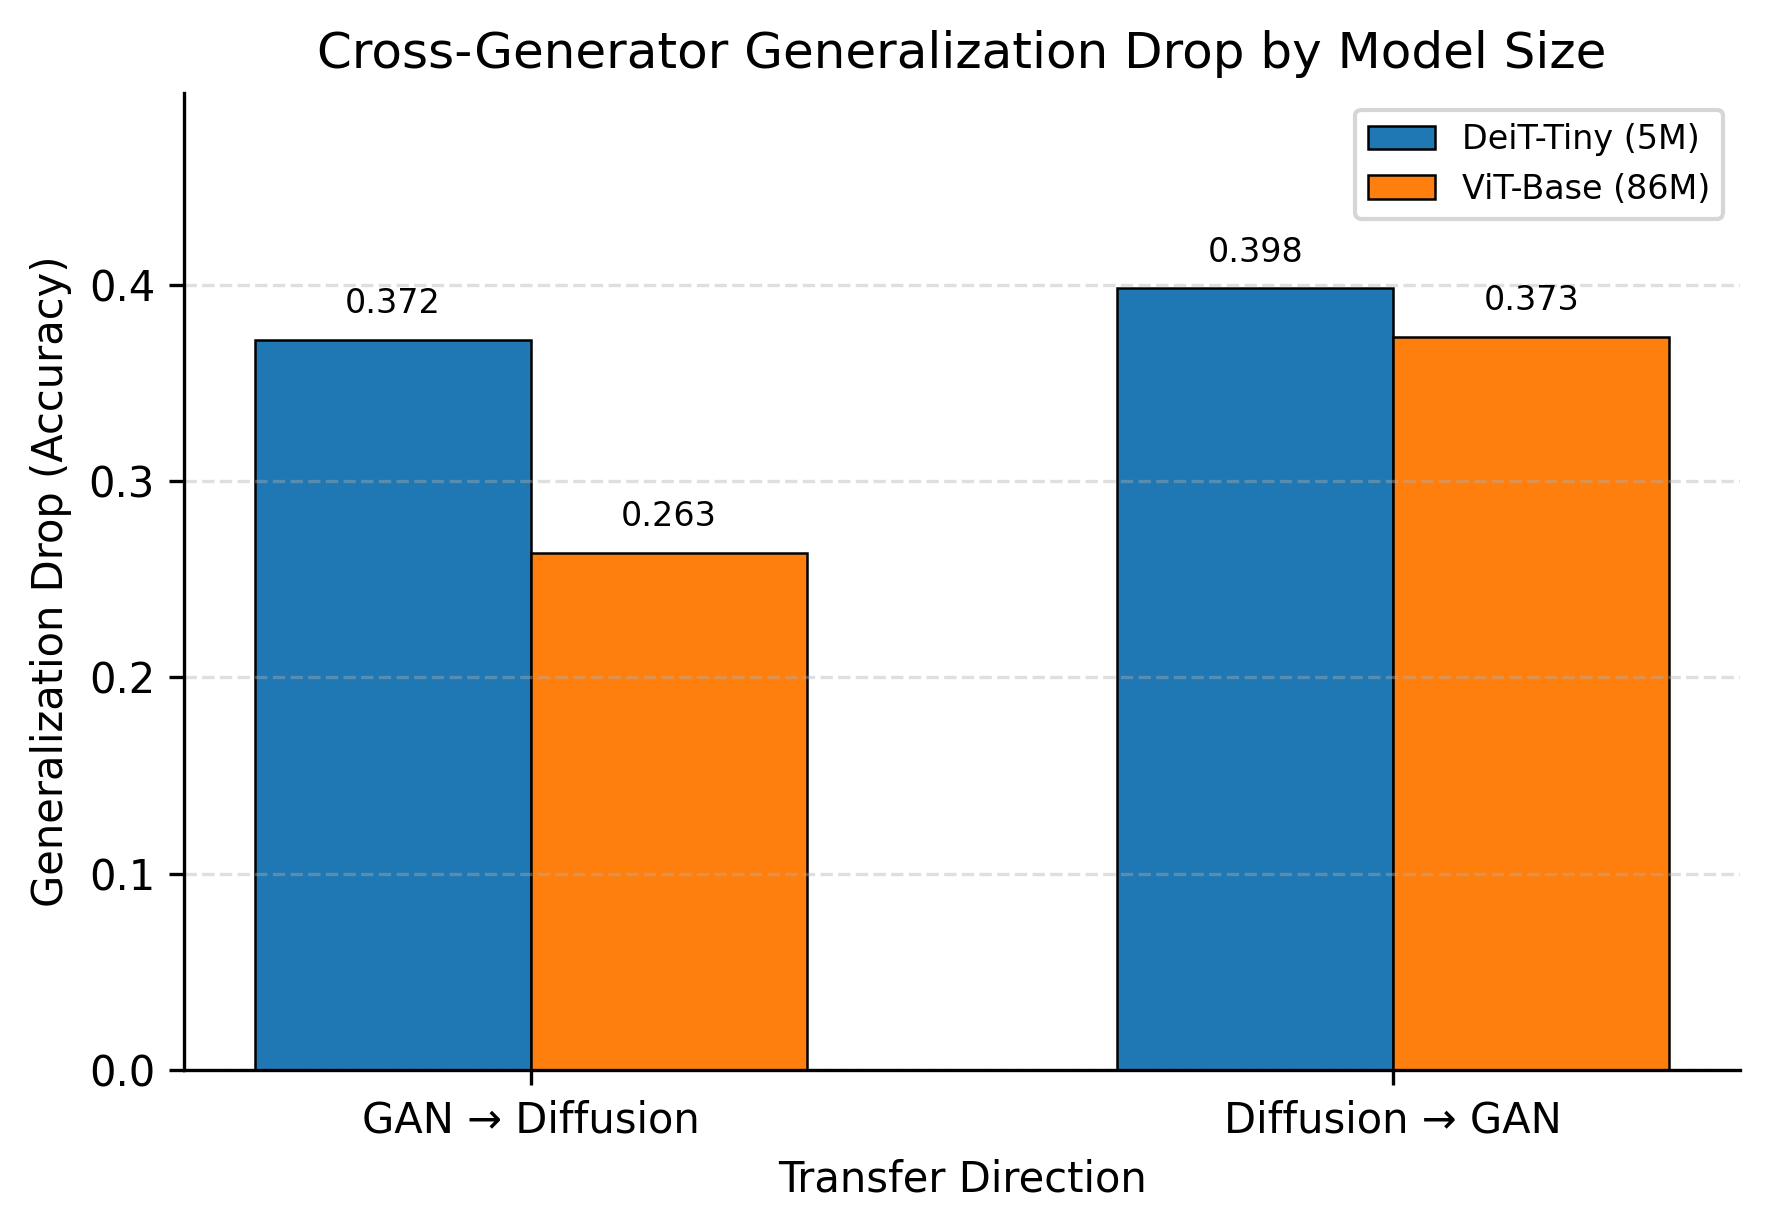

In [ ]:

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RESULTS_PATH = Path("results/results.json")
OUT_DIR = Path("results")
OUT_DIR.mkdir(exist_ok=True)

MODEL_LABELS = {
    "deit_tiny": "DeiT-Tiny (5M)",
    "vit_base": "ViT-Base (86M)",
}
DIRECTION_LABELS = {
    ("gan", "diffusion"): "GAN → Diffusion",
    ("diffusion", "gan"): "Diffusion → GAN",
}

with open(RESULTS_PATH) as f:
    results = json.load(f)

# ---------------------------------------------------------------------------
# TABLE
# ---------------------------------------------------------------------------
rows = []
for r in results:
    direction = DIRECTION_LABELS[(r["train_domain"], r["test_domain"])]
    model = MODEL_LABELS[r["model"]]
    rows.append({
        "Model": model,
        "Direction": direction,
        "Within-domain Acc": f"{r['within_domain_metrics']['accuracy']:.3f}",
        "Cross-domain Acc": f"{r['cross_domain_metrics']['accuracy']:.3f}",
        "Within-domain AUC": f"{r['within_domain_metrics']['auc']:.3f}",
        "Cross-domain AUC": f"{r['cross_domain_metrics']['auc']:.3f}",
        "Generalization Drop (Acc)": f"{r['generalization_drop_accuracy']:.3f}",
    })

# Markdown table
headers = list(rows[0].keys())
md_lines = ["| " + " | ".join(headers) + " |",
            "|" + "|".join(["---"] * len(headers)) + "|"]
for row in rows:
    md_lines.append("| " + " | ".join(str(row[h]) for h in headers) + " |")
md_table = "\n".join(md_lines)

with open(OUT_DIR / "results_table.md", "w") as f:
    f.write(md_table)
print("Markdown table:\n")
print(md_table)

# CSV
import csv
with open(OUT_DIR / "results_table.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=headers)
    writer.writeheader()
    writer.writerows(rows)

# ---------------------------------------------------------------------------
# FIGURE — grouped bar chart of Generalization Drop (Accuracy)
# ---------------------------------------------------------------------------
directions = ["GAN → Diffusion", "Diffusion → GAN"]
models = ["DeiT-Tiny (5M)", "ViT-Base (86M)"]

drop_lookup = {}
for r in results:
    direction = DIRECTION_LABELS[(r["train_domain"], r["test_domain"])]
    model = MODEL_LABELS[r["model"]]
    drop_lookup[(model, direction)] = r["generalization_drop_accuracy"]

x = np.arange(len(directions))
width = 0.32

fig, ax = plt.subplots(figsize=(6, 4.2), dpi=300)

for i, model in enumerate(models):
    values = [drop_lookup[(model, d)] for d in directions]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, values, width, label=model, edgecolor="black", linewidth=0.6)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}",
                 ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Generalization Drop (Accuracy)")
ax.set_xlabel("Transfer Direction")
ax.set_title("Cross-Generator Generalization Drop by Model Size")
ax.set_xticks(x)
ax.set_xticklabels(directions)
ax.set_ylim(0, max(drop_lookup.values()) * 1.25)
ax.legend(loc="upper right", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()
fig.savefig(OUT_DIR / "generalization_drop.png", dpi=300, bbox_inches="tight")
fig.savefig(OUT_DIR / "generalization_drop.pdf", bbox_inches="tight")

print(f"\nFigure saved to {OUT_DIR / 'generalization_drop.png'} and .pdf")
print(f"Table saved to {OUT_DIR / 'results_table.md'} and .csv")